In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Exibir todas as linhas
pd.set_option('display.max_rows', None)
# Exibir todas as colunas
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")
#!pip freeze > requirements.txt
df = pd.read_csv('../data/processed/netflix.csv')
movies = df[df['type'].str.contains('Movie', case=False, na=False)].copy()
movies['minutes'] = pd.to_numeric(movies['duration'],errors='coerce')


## TESTE DE HIPÓTESE

### DURAÇÃO DOS FILMES (1960-1990) VS (2000-2020)

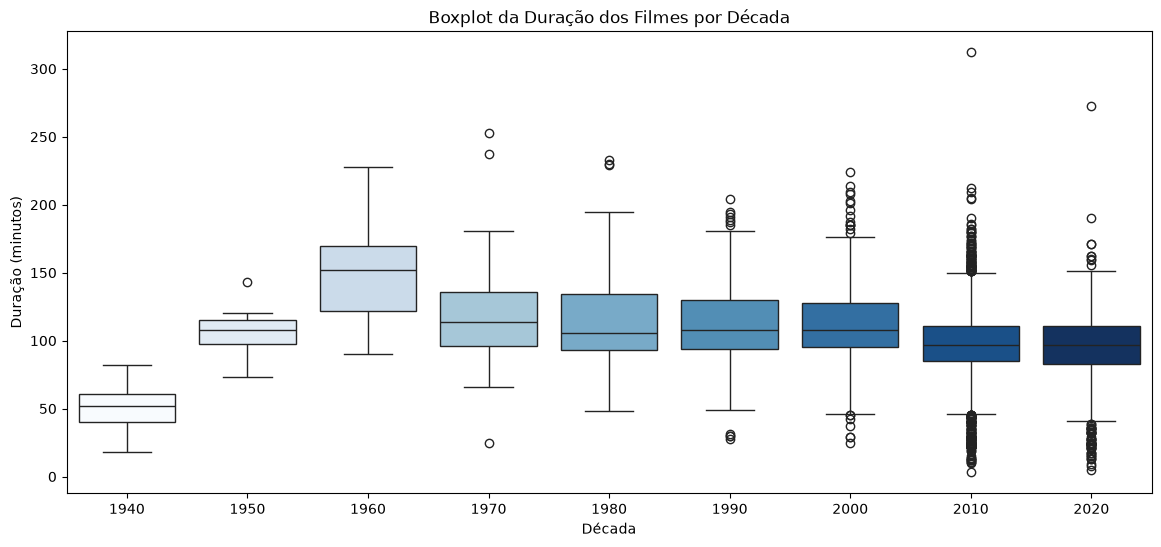

In [15]:
plt.figure(figsize=(14,6))
sns.boxplot(
    data=movies,
    x='release_decade',
    y='duration',
    hue='release_decade',          # usa a própria década como hue
    palette='Blues',
    legend=False           # remove legenda redundante
)

plt.title('Boxplot da Duração dos Filmes por Década')
plt.xlabel('Década')
plt.ylabel('Duração (minutos)')
plt.show()


In [16]:
recent = movies[
    (movies['release_year'] >= 2000) &
    (movies['release_year'] <= 2020)
]['minutes'].dropna()

old = movies[
    (movies['release_year'] >= 1960) &
    (movies['release_year'] < 2000)
]['minutes'].dropna()

result = stats.ttest_ind(
    recent,
    old,
    equal_var=False,
    alternative='less'
)

print(recent.mean(), old.mean())
print(result)

98.36203049460767 116.9933628318584
TtestResult(statistic=np.float64(-11.235150315645992), pvalue=np.float64(1.4400009877549587e-26), df=np.float64(499.33646691749385))


## Teste de hipótese: filmes mais recentes possuem menor duração?

Para investigar se filmes mais recentes tendem a apresentar menor duração, foi realizado um teste de hipótese comparando a duração média de dois grupos de filmes disponíveis no catálogo da Netflix:

- **Filmes lançados entre 1960 e 1999**;
- **Filmes lançados entre 2000 e 2020**.

A variável analisada foi a **duração dos filmes em minutos**.

### Formulação das hipóteses

Sejam:

- \(\mu_{2000-2020}\): duração média dos filmes lançados entre 2000 e 2020;
- \(\mu_{1960-1999}\): duração média dos filmes lançados entre 1960 e 1999.

As hipóteses foram definidas da seguinte forma:

\[
H_0: \mu_{2000-2020} \geq \mu_{1960-1999}
\]

\[
H_1: \mu_{2000-2020} < \mu_{1960-1999}
\]

A hipótese nula (\(H_0\)) estabelece que os filmes mais recentes possuem duração média igual ou superior à dos filmes mais antigos. Já a hipótese alternativa (\(H_1\)) afirma que os filmes lançados entre 2000 e 2020 apresentam duração média menor.

### Escolha do teste estatístico

Para comparar as médias dos dois grupos, foi utilizado o **teste t de Welch para duas amostras independentes**, na versão unilateral. Esse teste é apropriado quando se deseja comparar médias de grupos independentes sem assumir igualdade entre as variâncias populacionais.

### Estatísticas descritivas

A análise identificou:

| Grupo | Número de filmes | Duração média (min) |
|---------|------------------|---------------------|
| 1960–1999 | 452 | 116,99 |
| 2000–2020 | 5.378 | 98,36 |

Observa-se, descritivamente, que os filmes mais recentes apresentam duração média aproximadamente **18,6 minutos menor**.

### Resultados do teste

O teste t de Welch produziu os seguintes resultados:

- Estatística do teste: \(t = -11,24\);
- Graus de liberdade aproximados: \(df = 499,34\);
- Valor-p: \(p = 1,44 \times 10^{-26}\).

Considerando um nível de significância de 5% (\(\alpha = 0,05\)), verifica-se que:

\[
p < \alpha
\]

Portanto, **rejeita-se a hipótese nula**.

### Conclusão

Os resultados fornecem evidências estatísticas muito fortes de que os filmes lançados entre **2000 e 2020 possuem duração média significativamente menor** do que aqueles lançados entre **1960 e 1999** no catálogo analisado da Netflix.

Em termos práticos, a diferença observada sugere uma mudança no padrão de duração das produções cinematográficas ao longo do tempo, com filmes mais recentes tendendo a apresentar menor tempo de exibição.

### DURAÇÃO DOS FILMES DE DRAMA (1960-1990) VS (2000-2020)

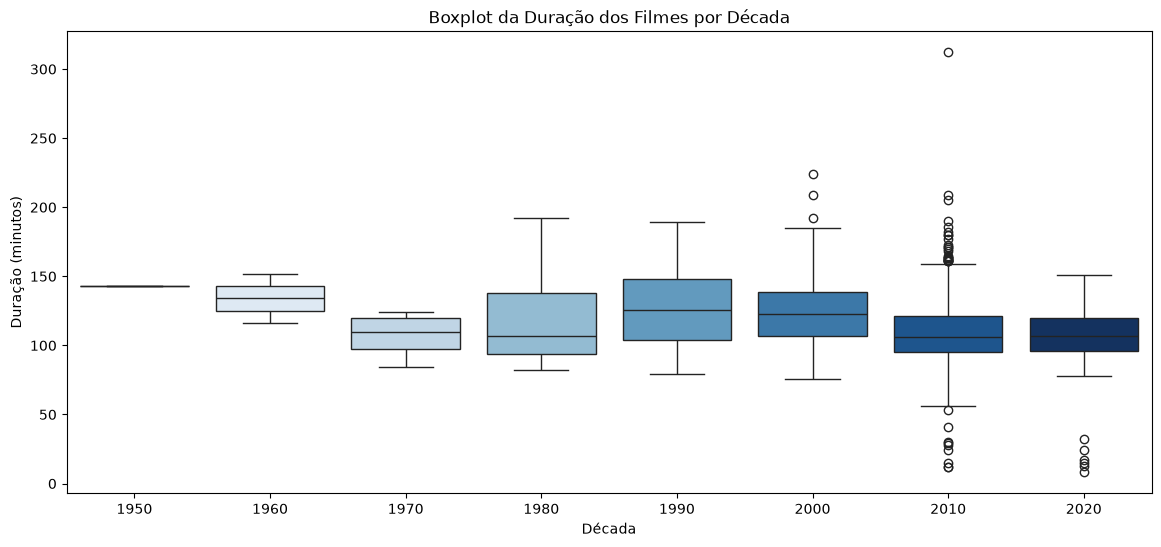

In [ ]:
# Seleciona apenas filmes
movies = df[df['type'] == 'Movie'].copy()

# Seleciona apenas filmes do gênero Drama
drama = movies[movies['genre'] == 'Drama'].copy()


plt.figure(figsize=(14,6))
sns.boxplot(
    data=drama,
    x='release_decade',
    y='duration',
    hue='release_decade',          # usa a própria década como hue
    palette='Blues',
    legend=False           # remove legenda redundante
)

plt.title('Boxplot da Duração dos Filmes de Drama por Década')
plt.xlabel('Década')
plt.ylabel('Duração (minutos)')
plt.show()

In [ ]:
# Seleciona apenas filmes
movies = df[df['type'] == 'Movie'].copy()

# Seleciona apenas filmes do gênero Drama
drama = movies[movies['genre'] == 'Drama'].copy()

# Define os grupos
drama_old = drama[
    (drama['release_year'] >= 1960) &
    (drama['release_year'] < 2000)
]['duration'].dropna()

drama_recent = drama[
    (drama['release_year'] >= 2000) &
    (drama['release_year'] <= 2020)
]['duration'].dropna()

# Estatísticas descritivas
results = pd.DataFrame({
    'Grupo': ['Drama (1960–1999)', 'Drama (2000–2020)'],
    'n': [len(drama_old), len(drama_recent)],
    'Média': [
        drama_old.mean(),
        drama_recent.mean()
    ],
    'Desvio-padrão': [
        drama_old.std(),
        drama_recent.std()
    ]
})

print('Estatísticas descritivas:')
print(results.round(2))
print()

# Teste t de Welch unilateral
t_stat, p_two_sided = ttest_ind(
    drama_recent,
    drama_old,
    equal_var=False
)

# Ajusta para hipótese unilateral
# H1: média recente < média antiga
if t_stat < 0:
    p_value = p_two_sided / 2
else:
    p_value = 1 - (p_two_sided / 2)

print('Teste t de Welch (unilateral)')
print(f'Estatística t: {t_stat:.3f}')
print(f'Valor-p: {p_value:.10f}')
print()

alpha = 0.05

print('Hipóteses:')
print('H0: μ_recente ≥ μ_antiga')
print('H1: μ_recente < μ_antiga')
print()

if p_value < alpha:
    print(
        f'Como p = {p_value:.5f} < {alpha}, '
        'rejeita-se H0.'
    )
    print(
        'Há evidências estatísticas de que filmes '
        'de drama lançados entre 2000 e 2020 possuem '
        'duração média menor do que dramas lançados '
        'entre 1960 e 1999.'
    )
else:
    print(
        f'Como p = {p_value:.5f} ≥ {alpha}, '
        'não se rejeita H0.'
    )
    print(
        'Não há evidências suficientes para afirmar '
        'que dramas mais recentes possuem duração '
        'média menor.'
    )

Estatísticas descritivas:
               Grupo     n   Média  Desvio-padrão
0  Drama (1960–1999)    90  123.92          28.72
1  Drama (2000–2020)  1452  110.66          23.21

Teste t de Welch (unilateral)
Estatística t: -4.294
Valor-p: 0.0000209273

Hipóteses:
H0: μ_recente ≥ μ_antiga
H1: μ_recente < μ_antiga

Como p = 0.00002 < 0.05, rejeita-se H0.
Há evidências estatísticas de que filmes de drama lançados entre 2000 e 2020 possuem duração média menor do que dramas lançados entre 1960 e 1999.


## Teste de hipótese: filmes de drama mais recentes possuem menor duração?

Para aprofundar a análise anterior, o teste foi repetido considerando **apenas os filmes classificados no gênero "Drama"**. O objetivo foi verificar se a redução na duração média dos filmes ao longo do tempo também é observada dentro de um único gênero cinematográfico.

A variável analisada continuou sendo a **duração dos filmes em minutos**.

### Formulação das hipóteses

Sejam:

- \(\mu_{2000-2020}\): duração média dos filmes de drama lançados entre 2000 e 2020;
- \(\mu_{1960-1999}\): duração média dos filmes de drama lançados entre 1960 e 1999.

As hipóteses foram definidas da seguinte forma:

\[
H_0: \mu_{2000-2020} \geq \mu_{1960-1999}
\]

\[
H_1: \mu_{2000-2020} < \mu_{1960-1999}
\]

A hipótese nula (\(H_0\)) estabelece que os dramas mais recentes possuem duração média igual ou superior à dos dramas mais antigos. A hipótese alternativa (\(H_1\)) afirma que os dramas lançados entre 2000 e 2020 apresentam duração média menor.

### Escolha do teste estatístico

Foi utilizado o **teste t de Welch para duas amostras independentes**, na versão unilateral. Esse procedimento é apropriado para comparar médias entre grupos independentes quando não se assume igualdade das variâncias populacionais.

### Estatísticas descritivas

A análise identificou os seguintes resultados:

| Grupo | Número de filmes | Duração média (min) | Desvio-padrão (min) |
|---------|------------------|---------------------|---------------------|
| Drama (1960–1999) | 90 | 123,92 | 28,72 |
| Drama (2000–2020) | 1.452 | 110,66 | 23,21 |

Descritivamente, observa-se que os dramas mais recentes possuem duração média aproximadamente **13,26 minutos menor** do que os dramas lançados antes dos anos 2000.

### Resultados do teste

O teste t de Welch produziu os seguintes resultados:

- Estatística do teste: \(t = -4,29\);
- Graus de liberdade aproximados: \(df = 96,34\);
- Valor-p: \(p = 0,000021\).

Considerando um nível de significância de 5% (\(\alpha = 0,05\)), verifica-se que:

\[
p < \alpha
\]

Portanto, **rejeita-se a hipótese nula**.

### Conclusão

Os resultados indicam que, mesmo restringindo a análise apenas aos **filmes do gênero Drama**, existe evidência estatística significativa de que os filmes lançados entre **2000 e 2020 apresentam duração média menor** do que aqueles lançados entre **1960 e 1999**.

Entretanto, observa-se que a magnitude dessa diferença foi menor quando comparada à análise realizada com todos os filmes do catálogo. Enquanto a redução média anteriormente observada foi de aproximadamente **18,6 minutos**, entre os dramas essa diferença caiu para cerca de **13,3 minutos**.

Esse resultado sugere que parte da redução geral na duração dos filmes pode estar associada a mudanças na composição dos gêneros presentes no catálogo ao longo do tempo. Ainda assim, mesmo controlando parcialmente esse efeito ao analisar apenas dramas, permanece a evidência de que produções mais recentes tendem a ser mais curtas.